# Physical Fields From Hamiltonians

This notebook is one chapter of the runnable `KnottedGraph` user guide.  It is
generated into `User_guide/04_physical_fields.ipynb` so users can open the specific workflow
they need without navigating one very large notebook.

- self-contained after the shared setup cells


## 0. Setup, Preflight, And Shared Plot Style

The whole notebook uses the same visual convention:

- blue: surfaces, skeleton points, and graph edges;
- red: graph vertices;
- black axes;
- paper notation: `Upsilon(G; Y)`.

The helper functions in this section remove repeated plotting boilerplate from
the rest of the notebook.  This is also the library-level pattern worth
promoting later into public visualization helpers.


In [1]:
from pathlib import Path
import sys
import importlib.util
import os
import tempfile

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DOC_ROOT = PROJECT_ROOT / "doc"
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "knottedgraph-mpl"))

print("project paths configured")
for package in ["numpy", "networkx", "sympy", "plotly", "matplotlib", "pyvista"]:
    print(f"{package:10s} = {importlib.util.find_spec(package) is not None}")


project paths configured
numpy      = True
networkx   = True
sympy      = True
plotly     = True
matplotlib = True
pyvista    = True


In [2]:
import math
import time

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import sympy as sp
from IPython.display import Math, display

from knotted_graph.projection import (
    compute_yamada_polynomial,
    sample_projections,
    select_projection,
)
from knotted_graph.visualization import plot_3D_graph_plotly

BLUE = "#1f77b4"
RED = "#d62728"
CAMERA = dict(eye=dict(x=1.45, y=1.55, z=1.18))
pio.renderers.default = "notebook_connected"
Y = sp.Symbol("Y")
kx, ky, kz = sp.symbols("k_x k_y k_z", real=True)


def axis_style():
    return dict(
        visible=True,
        title="",
        showticklabels=False,
        showbackground=False,
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=2,
    )


def apply_kg_layout(fig, *, width=760, height=620):
    fig.update_layout(
        title=None,
        width=width,
        height=height,
        margin=dict(l=0, r=0, t=0, b=0),
        scene=dict(
            xaxis=axis_style(),
            yaxis=axis_style(),
            zaxis=axis_style(),
            aspectmode="data",
            camera=CAMERA,
        ),
    )
    return fig


def plot_surface_polydata(surface, *, opacity=0.58):
    mesh = surface.triangulate()
    faces = mesh.faces.reshape(-1, 4)[:, 1:]
    pts = mesh.points
    fig = go.Figure(
        go.Mesh3d(
            x=pts[:, 0],
            y=pts[:, 1],
            z=pts[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            color=BLUE,
            opacity=opacity,
        )
    )
    return apply_kg_layout(fig)


def plot_points_3d(points, *, size=3):
    points = np.asarray(points)
    fig = go.Figure(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=dict(size=size, color=BLUE),
        )
    )
    return apply_kg_layout(fig)


def plot_graph_kg(graph):
    return apply_kg_layout(plot_3D_graph_plotly(graph))


def print_upsilon(label, expr):
    print(f"Upsilon({label}; Y) = {sp.expand(expr)}")


def display_bloch_vector(label, components):
    display(Math(label + r"=" + sp.latex(sp.Matrix(components))))


print("shared plotting and notation helpers ready")


shared plotting and notation helpers ready


In [3]:
from knotted_graph.applications.nodal import NodalSkeleton
from knotted_graph.applications.nodal.models import (
    awesome_bloch_vector,
    hopf_link_bloch_vector,
    pq_torus_knot_bloch_vector,
    solomon_bloch_vector,
    threelink_bloch_vector,
    trefoil_bloch_vector,
    unknot_bloch_vector,
)

print("nodal application imports ready")


nodal application imports ready


## 4. Physical Fields From The Same Hamiltonian

A non-Hermitian Hamiltonian produces field data, not only a skeleton graph.  In
`KnottedGraph`, this information is available through the same
`NodalSkeleton.fields_pv` object.  The examples below generate the
Berry-curvature and dispersion views directly from the public application
module.


In [4]:
field_model = hopf_link_bloch_vector(0.4, k_symbols=(kx, ky, kz))
display_bloch_vector(r"\vec d_{\mathrm{Hopf}}(\mathbf{k})", field_model)
field_ske = NodalSkeleton(
    field_model,
    k_symbols=(kx, ky, kz),
    dimension=36,
    axis_scale=(1.0, 1.0, 1.5),
)
field_surface = field_ske.exceptional_surface_pv.connectivity("largest")
field_volume = field_ske.fields_pv

print("available point-data arrays:")
for name in field_volume.point_data:
    arr = np.asarray(field_volume.point_data[name])
    print(f"  {name:20s} shape={arr.shape} min={np.nanmin(arr):.3g} max={np.nanmax(arr):.3g}")


<IPython.core.display.Math object>

available point-data arrays:
  imag                 shape=(46656,) min=0 max=0.399
  real                 shape=(46656,) min=0 max=27.2
  gap                  shape=(46656,) min=0.0508 max=54.5
  ES_helper            shape=(46656,) min=-0.399 max=27.2
  im_disp              shape=(46656, 3) min=-2.22 max=2.23
  |im_disp|            shape=(46656,) min=0 max=2.6
  log10(|im_disp|+1)   shape=(46656,) min=0 max=0.557
  berry                shape=(46656, 3) min=-5.52e+04 max=5.52e+04
  |berry|              shape=(46656,) min=0 max=6.92e+04
  log10(|berry|+1)     shape=(46656,) min=0 max=4.84


In [5]:
points = field_volume.points
berry_vec = np.asarray(field_volume.point_data["berry"])
berry_strength = np.linalg.norm(berry_vec, axis=1)
finite = np.isfinite(berry_strength) & (berry_strength > 0)
candidate = np.flatnonzero(finite)
if len(candidate) > 220:
    ranked = candidate[np.argsort(berry_strength[candidate])[-220:]]
else:
    ranked = candidate

mesh = field_surface.triangulate()
faces = mesh.faces.reshape(-1, 4)[:, 1:]
pts = mesh.points

fig = go.Figure()
fig.add_trace(
    go.Mesh3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        color=BLUE,
        opacity=0.22,
        showscale=False,
    )
)
fig.add_trace(
    go.Cone(
        x=points[ranked, 0],
        y=points[ranked, 1],
        z=points[ranked, 2],
        u=berry_vec[ranked, 0],
        v=berry_vec[ranked, 1],
        w=berry_vec[ranked, 2],
        colorscale="Blues",
        showscale=False,
        sizemode="absolute",
        sizeref=0.055,
        opacity=0.78,
    )
)
apply_kg_layout(fig).show()


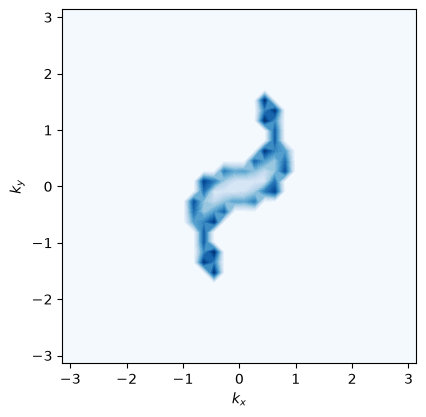

In [6]:
dispersion_scalar = np.asarray(field_volume.point_data["log10(|im_disp|+1)"])
grid_shape = field_ske.kx_grid.shape
dispersion_grid = dispersion_scalar.reshape(grid_shape, order="F")
middle = grid_shape[2] // 2

fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.contourf(
    field_ske.kx_grid[:, :, middle],
    field_ske.ky_grid[:, :, middle],
    dispersion_grid[:, :, middle],
    levels=28,
    cmap="Blues",
)
ax.set_aspect("equal")
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
plt.show()


The surface-mode helper is available under
`knotted_graph.applications.nodal.surface_modes`.  The grid below is deliberately
small so `Run All` stays practical: Hamiltonian to open-boundary batches,
eigenvalues, then a surface-mode plot.


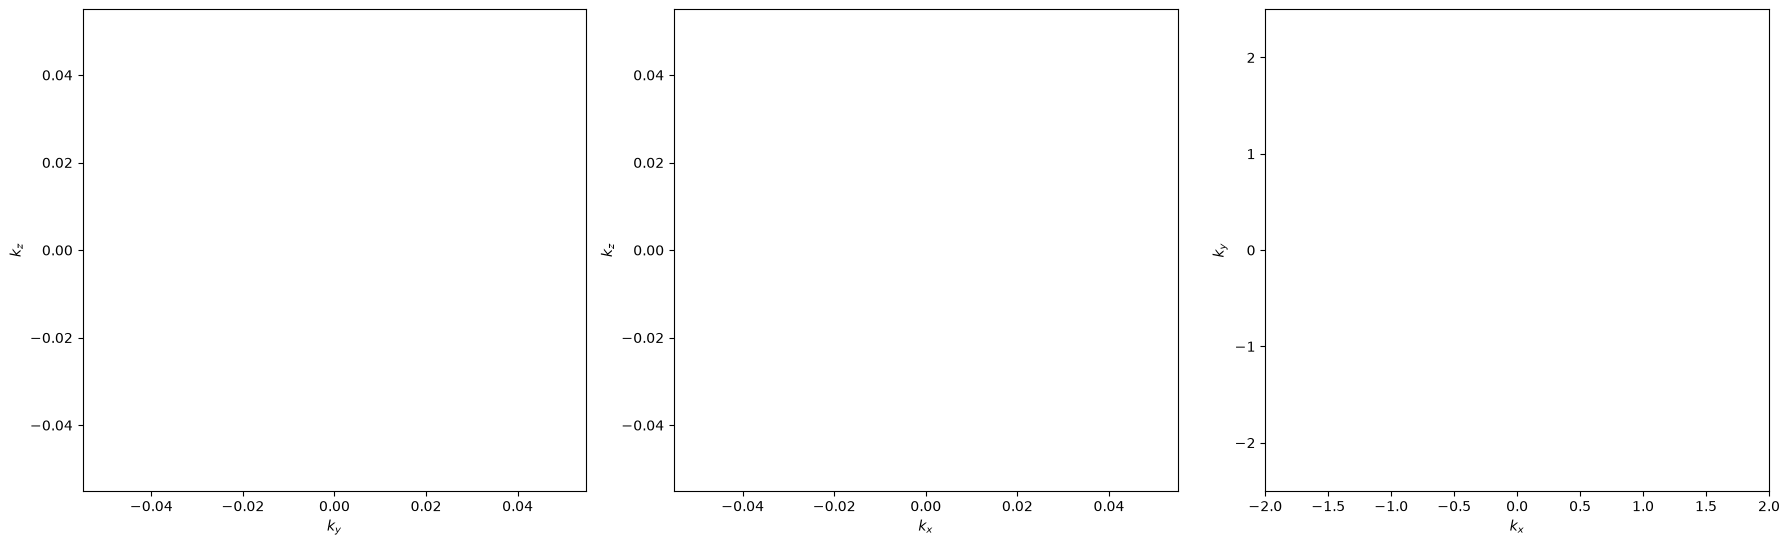

In [7]:
from poly2graph import eig_batch

from knotted_graph.applications.nodal.surface_modes import H_batch
from knotted_graph.applications.nodal.visualization import plot_surface_modes

sigma_x = sp.ImmutableMatrix([[0, 1], [1, 0]])
sigma_z = sp.ImmutableMatrix([[1, 0], [0, -1]])


def h_hopf_hermitian(kx_value, ky_value, kz_value):
    z = sp.cos(2 * kz_value) + sp.Rational(1, 2) + sp.I * (
        sp.cos(kx_value) + sp.cos(ky_value) + sp.cos(kz_value) - 2
    )
    w = sp.sin(kx_value) + sp.I * sp.sin(ky_value)
    f_value = z**2 - w**2
    return sp.simplify(sp.re(f_value) * sigma_x + sp.im(f_value) * sigma_z)


k_grid_small = np.linspace(-np.pi, np.pi, 8)
chain_length = 4
h_obc_x, _ = H_batch(h_hopf_hermitian, "x", chain_length, k_grid_small, k_grid_small)
h_obc_y, _ = H_batch(h_hopf_hermitian, "y", chain_length, k_grid_small, k_grid_small)
h_obc_z, _ = H_batch(h_hopf_hermitian, "z", chain_length, k_grid_small, k_grid_small)
eig_x, _ = eig_batch(h_obc_x)
eig_y, _ = eig_batch(h_obc_y)
eig_z, _ = eig_batch(h_obc_z)

fig = plot_surface_modes(
    (eig_x, eig_y, eig_z),
    (k_grid_small, k_grid_small, k_grid_small),
    (0.04, 0.07, 0.07),
    nH_coeff=0.0,
)
for ax in fig.axes:
    ax.set_title("")
plt.show()
